# 03. Baseline Models

Notebook này ghi lại kết quả của **Giai đoạn 3 — Baseline Models**.

Vai trò của notebook:

- Không train lại model.
- Không chứa toàn bộ logic huấn luyện.
- Chỉ đọc output đã sinh ra từ `scripts/train_baselines.py`.
- Hiển thị bảng kết quả, classification report và confusion matrix.
- Phân tích baseline để làm mốc so sánh với PhoBERT.

Các baseline đã chạy:

```text
1. Majority Class
2. TF-IDF word-level + Linear SVM
3. TF-IDF char-level + Linear SVM
```

Các task:

```text
1. Sentiment classification
2. Topic classification
```

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Project root:", ROOT)

TABLES_DIR = ROOT / "outputs" / "tables"
FIGURES_DIR = ROOT / "outputs" / "figures"
PREDICTIONS_DIR = ROOT / "outputs" / "predictions"
MODELS_DIR = ROOT / "outputs" / "models" / "baseline"
REPORTS_DIR = ROOT / "outputs" / "reports"

Project root: d:\project-ml-engineering\viedufeedback-robust


## 2. Kiểm tra file output bắt buộc

In [2]:
required_files = {
    "baseline_results": TABLES_DIR / "baseline_results.csv",
    "baseline_classification_report": TABLES_DIR / "baseline_classification_report.csv",
    "baseline_predictions": PREDICTIONS_DIR / "baseline_predictions.csv",
    "baseline_report": REPORTS_DIR / "baseline_report.md",
}

check_df = pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in required_files.items()]
)

display(check_df)

missing = check_df.loc[~check_df["exists"], "name"].tolist()
if missing:
    raise FileNotFoundError(f"Missing required baseline files: {missing}")

print("All required Stage 3 files exist.")

,name,path,exists
0,baseline_results,d:\project-ml-engineering\viedufeedback-robust...,True
1,baseline_classification_report,d:\project-ml-engineering\viedufeedback-robust...,True
2,baseline_predictions,d:\project-ml-engineering\viedufeedback-robust...,True
3,baseline_report,d:\project-ml-engineering\viedufeedback-robust...,True


All required Stage 3 files exist.


## 3. Kết quả tổng hợp baseline

Metric chính là **Macro-F1** vì EDA cho thấy cả sentiment và topic đều mất cân bằng lớp.

In [3]:
baseline_results = pd.read_csv(TABLES_DIR / "baseline_results.csv")
display(baseline_results)

,task,model,split,accuracy,macro_f1,weighted_f1
0,sentiment,tfidf_char_svm,test,0.875237,0.738784,0.876528
1,sentiment,tfidf_word_svm,test,0.891977,0.728904,0.887000
2,sentiment,majority,test,0.502211,0.222876,0.335793
3,sentiment,tfidf_word_svm,validation,0.910929,0.768048,0.908651
4,sentiment,tfidf_char_svm,validation,0.899558,0.766947,0.902882
5,sentiment,majority,validation,0.508528,0.224735,0.342852
6,topic,tfidf_word_svm,test,0.858497,0.750922,0.859847
7,topic,tfidf_char_svm,test,0.833544,0.732207,0.840575
8,topic,majority,test,0.723310,0.209861,0.607178
9,topic,tfidf_word_svm,validation,0.864814,0.761481,0.865695


## 4. Kết quả trên test set

Bảng này là mốc chính để so sánh với PhoBERT ở các giai đoạn sau.

In [4]:
test_results = baseline_results[baseline_results["split"] == "test"].copy()
test_results = test_results.sort_values(["task", "macro_f1"], ascending=[True, False])
display(test_results)

best_by_task = (
    test_results.sort_values(["task", "macro_f1"], ascending=[True, False])
    .groupby("task")
    .head(1)
    .reset_index(drop=True)
)

display(Markdown("### Best baseline by Macro-F1 on test set"))
display(best_by_task)

,task,model,split,accuracy,macro_f1,weighted_f1
0,sentiment,tfidf_char_svm,test,0.875237,0.738784,0.876528
1,sentiment,tfidf_word_svm,test,0.891977,0.728904,0.887000
2,sentiment,majority,test,0.502211,0.222876,0.335793
6,topic,tfidf_word_svm,test,0.858497,0.750922,0.859847
7,topic,tfidf_char_svm,test,0.833544,0.732207,0.840575
8,topic,majority,test,0.723310,0.209861,0.607178


### Best baseline by Macro-F1 on test set

,task,model,split,accuracy,macro_f1,weighted_f1
0,sentiment,tfidf_char_svm,test,0.875237,0.738784,0.876528
1,topic,tfidf_word_svm,test,0.858497,0.750922,0.859847


## 5. Sentiment baseline analysis

In [5]:
sentiment_test = test_results[test_results["task"] == "sentiment"].copy()
display(sentiment_test)

best_sentiment = sentiment_test.sort_values("macro_f1", ascending=False).iloc[0]
display(Markdown(
    f"Best sentiment baseline by Macro-F1: **{best_sentiment['model']}** "
    f"(Macro-F1 = **{best_sentiment['macro_f1']:.4f}**, "
    f"Accuracy = **{best_sentiment['accuracy']:.4f}**)."
))

,task,model,split,accuracy,macro_f1,weighted_f1
0,sentiment,tfidf_char_svm,test,0.875237,0.738784,0.876528
1,sentiment,tfidf_word_svm,test,0.891977,0.728904,0.887000
2,sentiment,majority,test,0.502211,0.222876,0.335793


Best sentiment baseline by Macro-F1: **tfidf_char_svm** (Macro-F1 = **0.7388**, Accuracy = **0.8752**).

### Nhận xét sentiment

Ghi nhận chính:

```text
- Majority baseline có Accuracy không quá thấp nhưng Macro-F1 rất thấp.
- Điều này xác nhận Accuracy không đủ đáng tin trên dữ liệu mất cân bằng.
- TF-IDF word SVM thường có Accuracy cao.
- TF-IDF char SVM có thể cải thiện Macro-F1 nhờ xử lý tốt hơn lớp nhỏ neutral.
```

Khi so sánh PhoBERT cho sentiment, mốc cần vượt là baseline có Macro-F1 cao nhất trên test set.

## 6. Topic baseline analysis

In [6]:
topic_test = test_results[test_results["task"] == "topic"].copy()
display(topic_test)

best_topic = topic_test.sort_values("macro_f1", ascending=False).iloc[0]
display(Markdown(
    f"Best topic baseline by Macro-F1: **{best_topic['model']}** "
    f"(Macro-F1 = **{best_topic['macro_f1']:.4f}**, "
    f"Accuracy = **{best_topic['accuracy']:.4f}**)."
))

,task,model,split,accuracy,macro_f1,weighted_f1
6,topic,tfidf_word_svm,test,0.858497,0.750922,0.859847
7,topic,tfidf_char_svm,test,0.833544,0.732207,0.840575
8,topic,majority,test,0.723310,0.209861,0.607178


Best topic baseline by Macro-F1: **tfidf_word_svm** (Macro-F1 = **0.7509**, Accuracy = **0.8585**).

### Nhận xét topic

Ghi nhận chính:

```text
- Majority baseline topic có Accuracy cao vì lớp lecturer chiếm đa số.
- Nhưng Macro-F1 rất thấp, chứng minh model không học được các lớp nhỏ.
- TF-IDF word SVM là baseline mạnh cho topic nếu có Macro-F1 cao nhất.
- Lớp others cần phân tích kỹ vì đây thường là lớp rộng và mơ hồ.
```

Khi so sánh PhoBERT cho topic, không chỉ xem Accuracy. Phải xem Macro-F1 và per-class F1.

## 7. Classification report

Phần này kiểm tra chi tiết Precision, Recall, F1 theo từng lớp.

In [7]:
classification_report_df = pd.read_csv(TABLES_DIR / "baseline_classification_report.csv")
display(classification_report_df.head(20))

,task,model,split,label,precision,recall,f1_score,support
0,sentiment,majority,validation,negative,0.000000,0.000000,0.000000,705.0
1,sentiment,majority,validation,neutral,0.000000,0.000000,0.000000,73.0
2,sentiment,majority,validation,positive,0.508528,1.000000,0.674204,805.0
3,sentiment,majority,validation,accuracy,NaN,NaN,0.508528,NaN
4,sentiment,majority,validation,macro avg,0.169509,0.333333,0.224735,1583.0
5,sentiment,majority,validation,weighted avg,0.258601,0.508528,0.342852,1583.0
6,sentiment,majority,test,negative,0.000000,0.000000,0.000000,1409.0
7,sentiment,majority,test,neutral,0.000000,0.000000,0.000000,167.0
8,sentiment,majority,test,positive,0.502211,1.000000,0.668629,1590.0
9,sentiment,majority,test,accuracy,NaN,NaN,0.502211,NaN


## 8. Per-class F1 trên test set

Tập trung vào các lớp nhỏ:

```text
Sentiment:
- neutral

Topic:
- facility
- others
```

In [8]:
test_class_report = classification_report_df[
    (classification_report_df["split"] == "test")
].copy()

# Loại bỏ các dòng tổng hợp để xem nhãn thật
summary_labels = {"accuracy", "macro avg", "weighted avg"}
per_class_test = test_class_report[~test_class_report["label"].isin(summary_labels)].copy()

display(per_class_test.sort_values(["task", "model", "f1_score"]))

display(Markdown("### Lowest per-class F1 cases"))
display(per_class_test.sort_values("f1_score").head(10))

,task,model,split,label,precision,recall,f1_score,support
6,sentiment,majority,test,negative,0.000000,0.000000,0.000000,1409.0
7,sentiment,majority,test,neutral,0.000000,0.000000,0.000000,167.0
8,sentiment,majority,test,positive,0.502211,1.000000,0.668629,1590.0
31,sentiment,tfidf_char_svm,test,neutral,0.395604,0.431138,0.412607,167.0
30,sentiment,tfidf_char_svm,test,negative,0.880248,0.907736,0.893781,1409.0
32,sentiment,tfidf_char_svm,test,positive,0.927498,0.893082,0.909965,1590.0
19,sentiment,tfidf_word_svm,test,neutral,0.445455,0.293413,0.353791,167.0
18,sentiment,tfidf_word_svm,test,negative,0.882119,0.945351,0.912641,1409.0
20,sentiment,tfidf_word_svm,test,positive,0.933376,0.907547,0.920281,1590.0
44,topic,majority,test,training_program,0.000000,0.000000,0.000000,572.0


### Lowest per-class F1 cases

,task,model,split,label,precision,recall,f1_score,support
6,sentiment,majority,test,negative,0.000000,0.000000,0.000000,1409.0
46,topic,majority,test,others,0.000000,0.000000,0.000000,159.0
45,topic,majority,test,facility,0.000000,0.000000,0.000000,145.0
44,topic,majority,test,training_program,0.000000,0.000000,0.000000,572.0
7,sentiment,majority,test,neutral,0.000000,0.000000,0.000000,167.0
19,sentiment,tfidf_word_svm,test,neutral,0.445455,0.293413,0.353791,167.0
31,sentiment,tfidf_char_svm,test,neutral,0.395604,0.431138,0.412607,167.0
60,topic,tfidf_word_svm,test,others,0.478873,0.427673,0.451827,159.0
74,topic,tfidf_char_svm,test,others,0.399083,0.547170,0.461538,159.0
8,sentiment,majority,test,positive,0.502211,1.000000,0.668629,1590.0


## 9. Confusion matrices

Các hình dưới đây giúp kiểm tra model nhầm lớp nào sang lớp nào. Với dữ liệu mất cân bằng, confusion matrix rất quan trọng.

### sentiment — majority — test

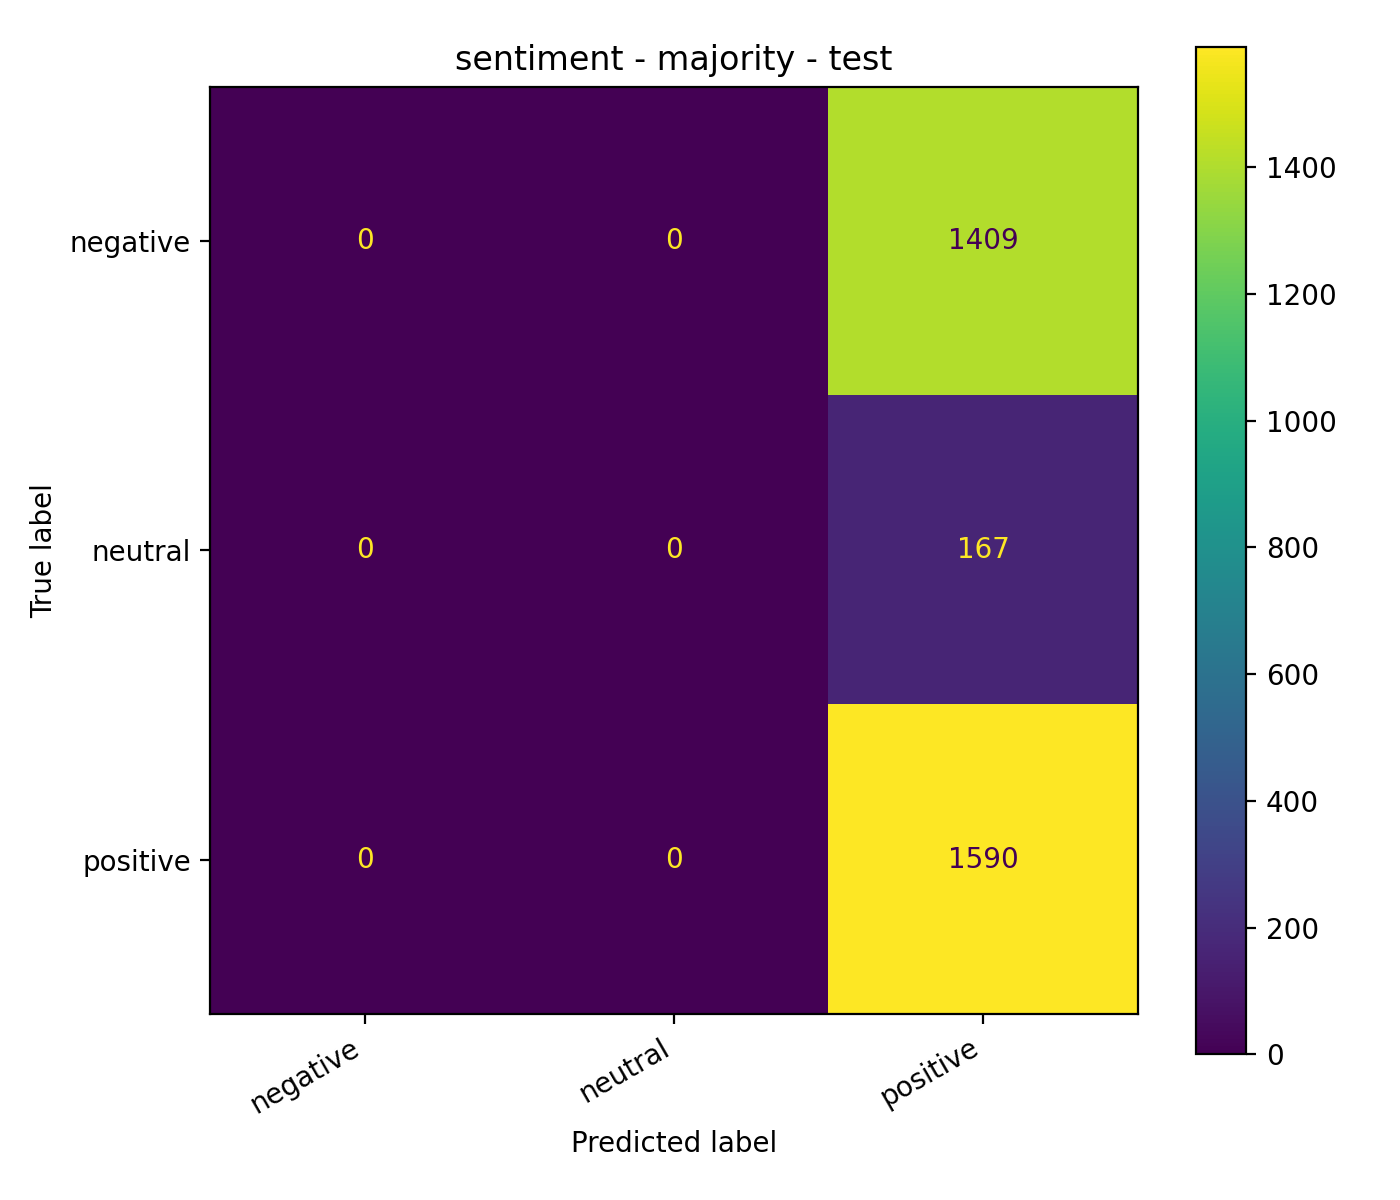

### sentiment — tfidf_word_svm — test

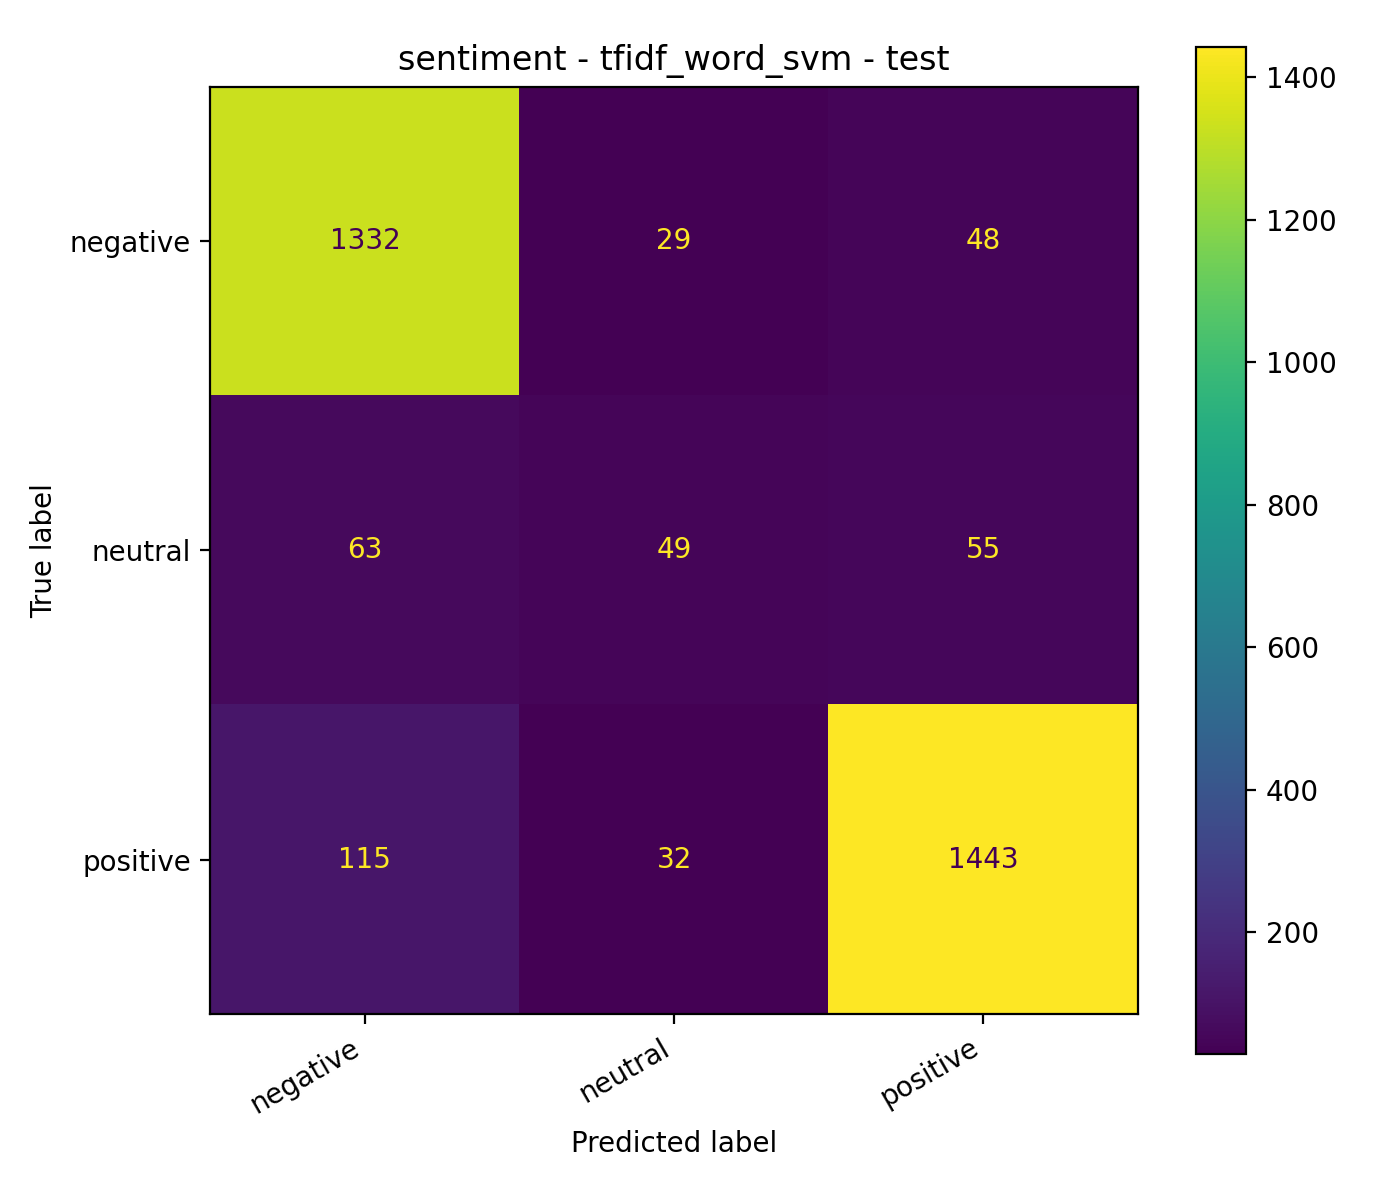

### sentiment — tfidf_char_svm — test

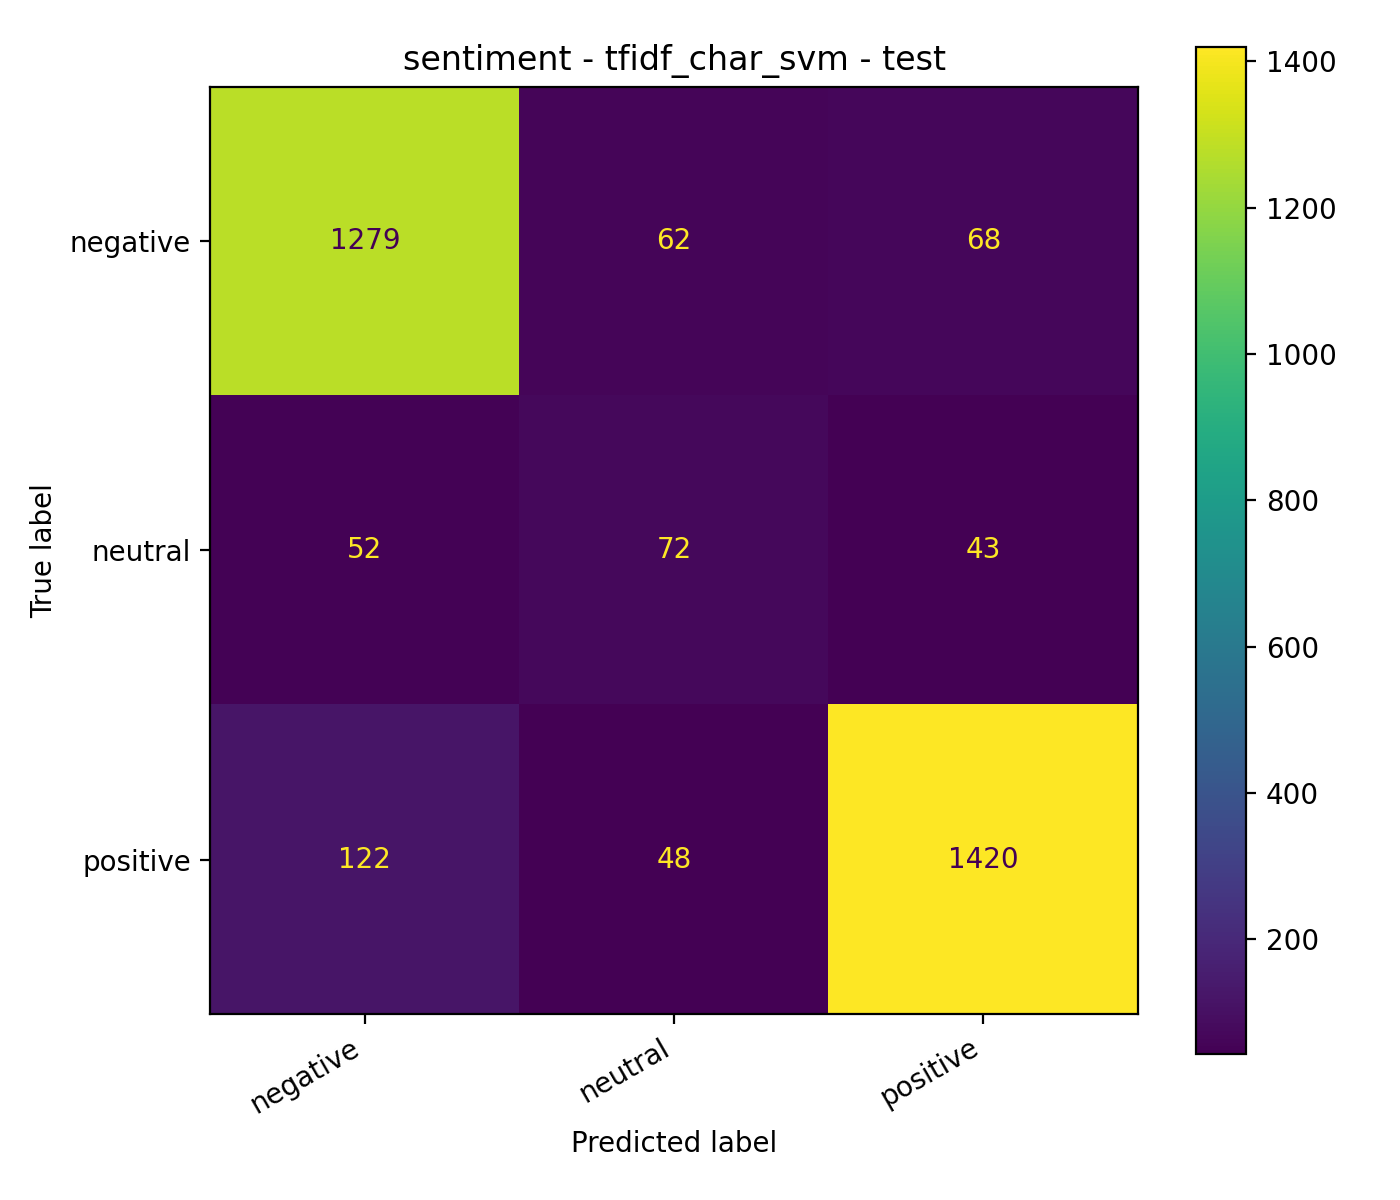

### topic — majority — test

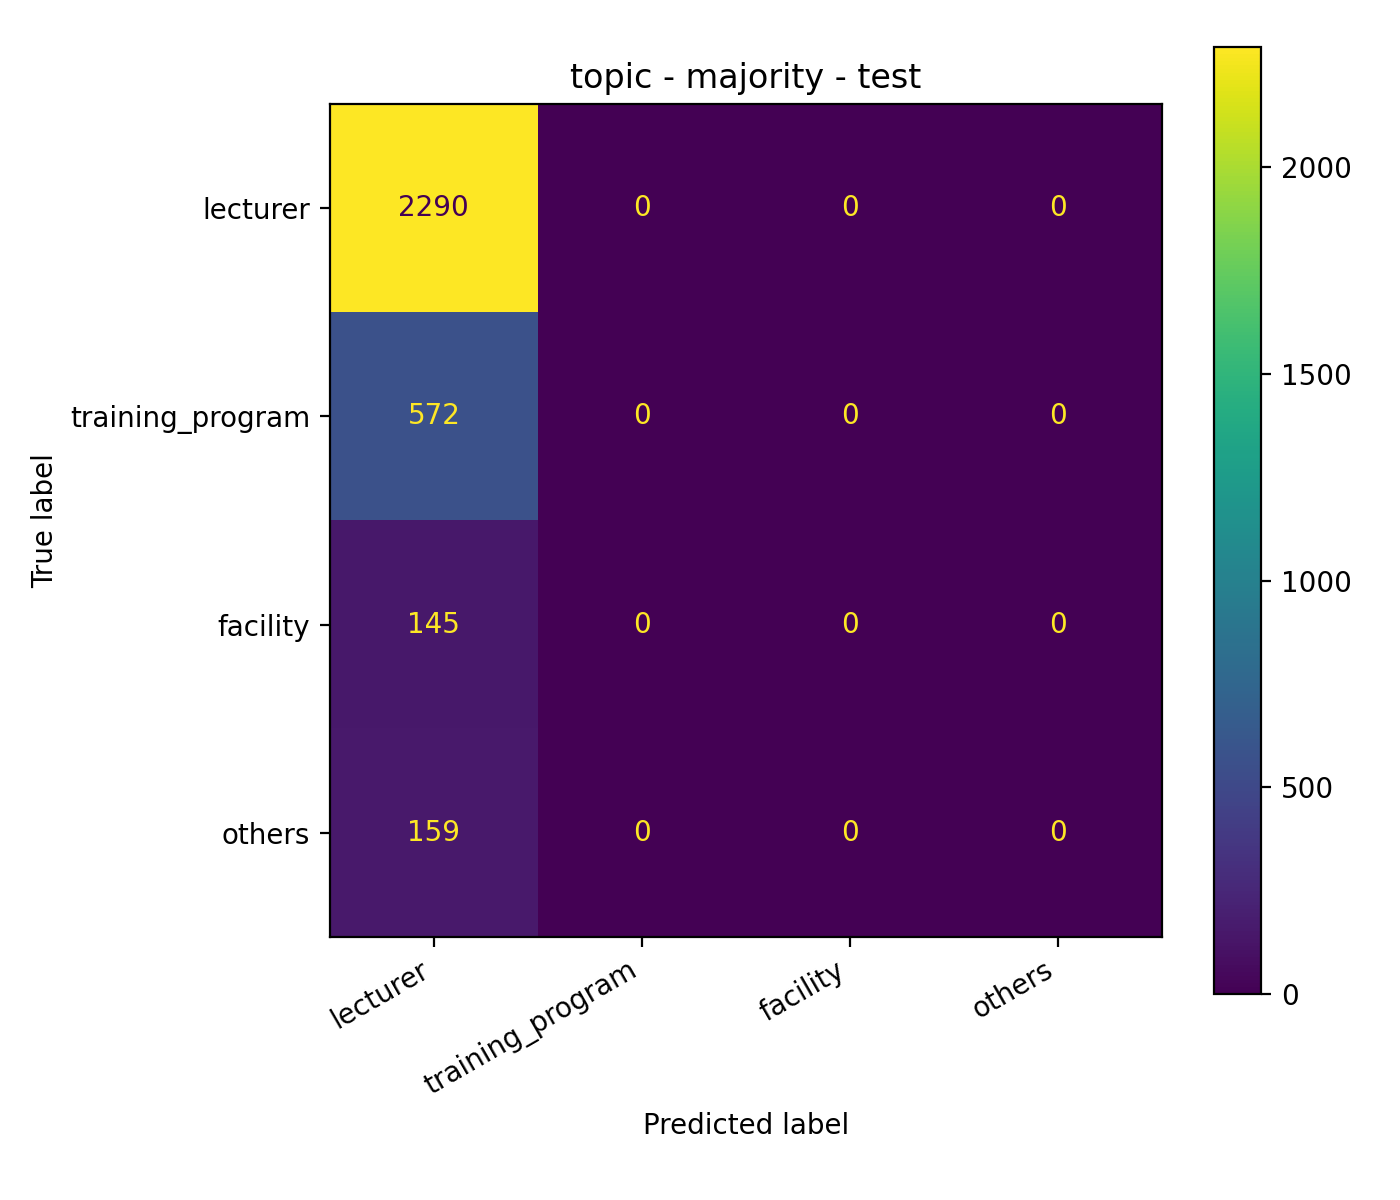

### topic — tfidf_word_svm — test

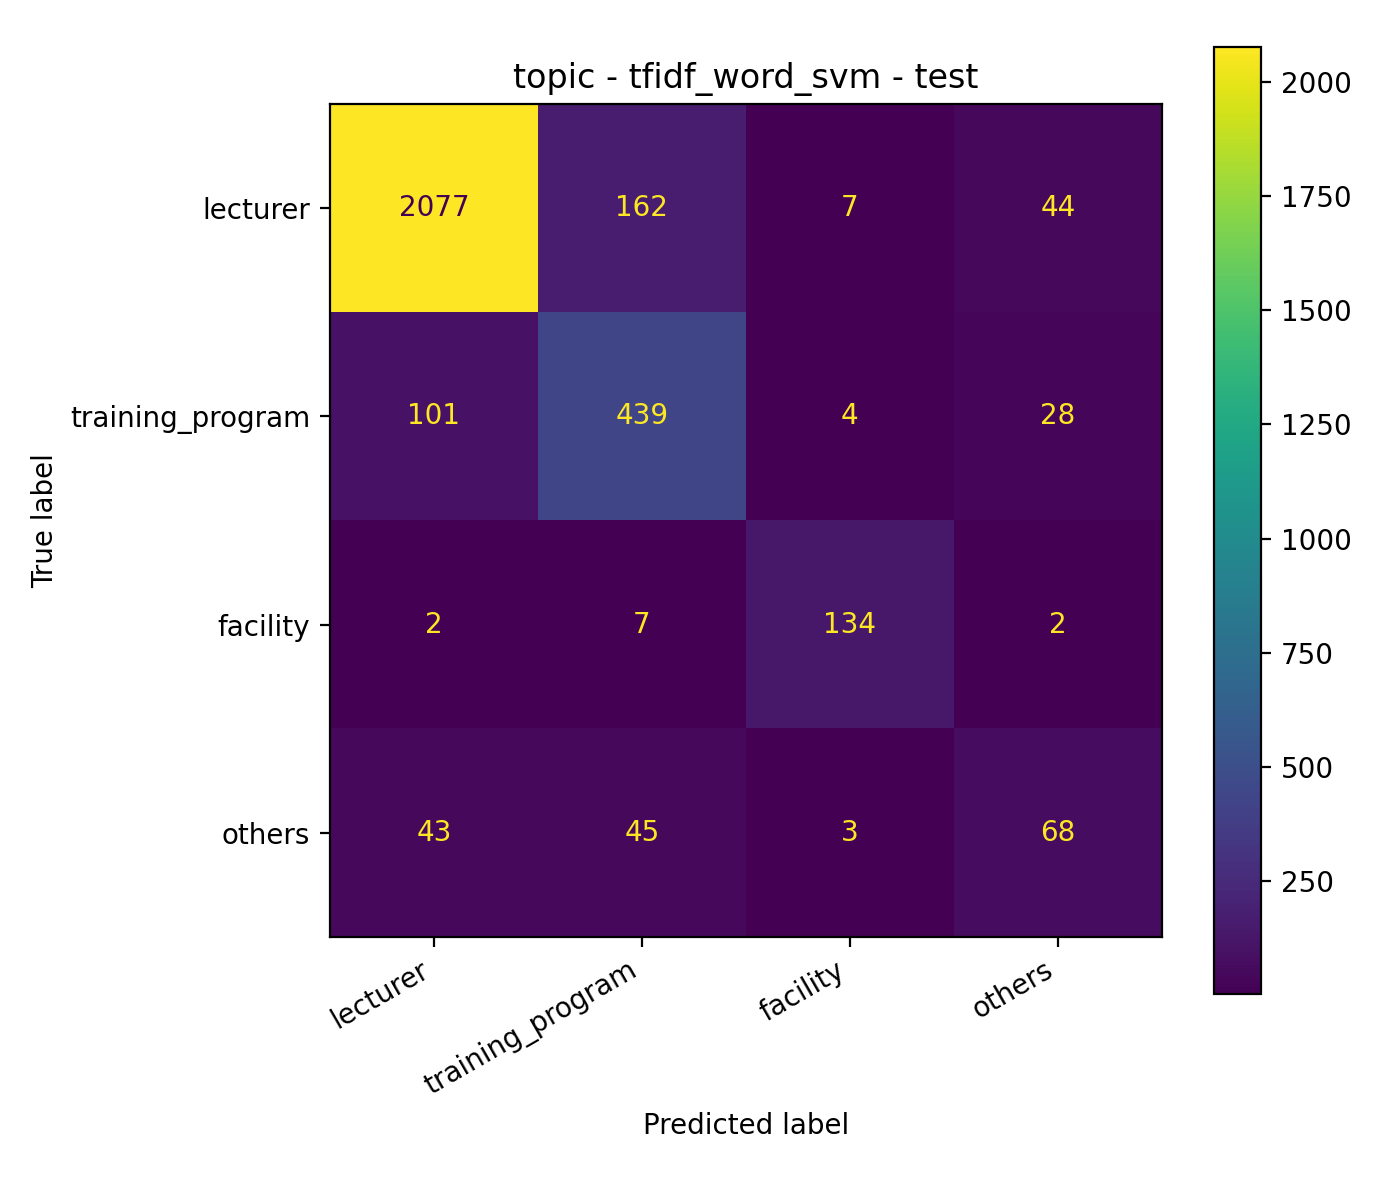

### topic — tfidf_char_svm — test

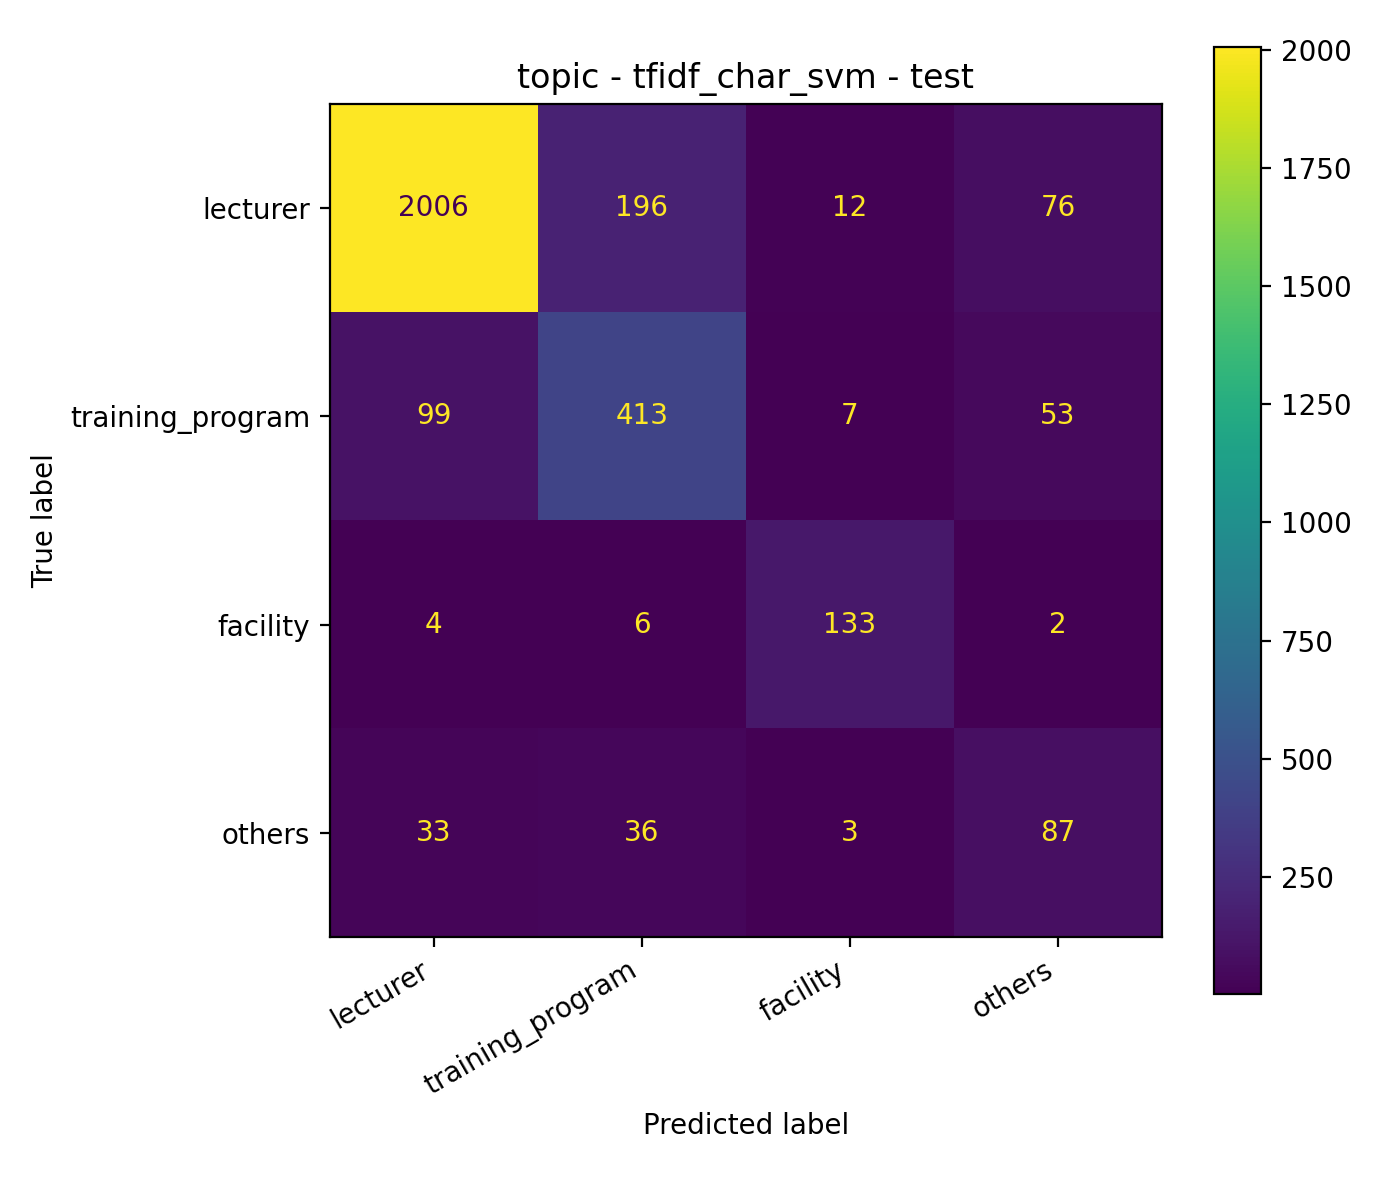

In [9]:
def show_confusion_matrix(task: str, model: str, split: str = "test"):
    path = FIGURES_DIR / f"confusion_matrix_baseline_{task}_{model}_{split}.png"
    if not path.exists():
        display(Markdown(f"Missing confusion matrix: `{path}`"))
        return
    display(Markdown(f"### {task} — {model} — {split}"))
    display(Image(filename=str(path)))

for task in ["sentiment", "topic"]:
    for model in ["majority", "tfidf_word_svm", "tfidf_char_svm"]:
        show_confusion_matrix(task, model, split="test")

## 10. Validation vs Test stability

Mục tiêu: kiểm tra kết quả validation và test có chênh lệch bất thường không.

In [10]:
stability = baseline_results.pivot_table(
    index=["task", "model"],
    columns="split",
    values="macro_f1"
).reset_index()

if "validation" in stability.columns and "test" in stability.columns:
    stability["val_test_macro_f1_gap"] = stability["validation"] - stability["test"]

display(stability)

split,task,model,test,validation,val_test_macro_f1_gap
0,sentiment,majority,0.222876,0.224735,0.001858
1,sentiment,tfidf_char_svm,0.738784,0.766947,0.028163
2,sentiment,tfidf_word_svm,0.728904,0.768048,0.039144
3,topic,majority,0.209861,0.210497,0.000637
4,topic,tfidf_char_svm,0.732207,0.728565,-0.003642
5,topic,tfidf_word_svm,0.750922,0.761481,0.010559


## 11. Baseline conclusions

Kết luận cần ghi cho báo cáo:

```text
1. Majority baseline cho thấy cả hai task bị ảnh hưởng bởi mất cân bằng lớp.
2. Accuracy không đủ để đánh giá, đặc biệt với topic vì lecturer chiếm đa số.
3. TF-IDF/SVM vượt xa Majority, nên đây là baseline hợp lý trước khi dùng PhoBERT.
4. Với sentiment, cần chú ý lớp neutral vì đây là lớp nhỏ và dễ bị bỏ qua.
5. Với topic, cần chú ý facility và others, đặc biệt others vì bản chất lớp này rộng và mơ hồ.
6. PhoBERT ở giai đoạn sau phải được so sánh chủ yếu bằng Macro-F1 và per-class F1.
```

Baseline chính để so sánh với PhoBERT:

```text
Sentiment:
- Chọn model có Macro-F1 test cao nhất.

Topic:
- Chọn model có Macro-F1 test cao nhất.
```

In [11]:
display(Markdown("### Final baseline reference"))
for _, row in best_by_task.iterrows():
    display(Markdown(
        f"- **{row['task']}**: `{row['model']}` "
        f"with Macro-F1 = **{row['macro_f1']:.4f}**, "
        f"Accuracy = **{row['accuracy']:.4f}**"
    ))

### Final baseline reference

- **sentiment**: `tfidf_char_svm` with Macro-F1 = **0.7388**, Accuracy = **0.8752**

- **topic**: `tfidf_word_svm` with Macro-F1 = **0.7509**, Accuracy = **0.8585**

## 12. Stage 3 status

Giai đoạn Baseline hoàn thành khi có đủ:

```text
- baseline_results.csv
- baseline_classification_report.csv
- baseline_predictions.csv
- confusion_matrix_baseline_*.png
- baseline_report.md
- baseline model artifacts trong outputs/models/baseline/
```

Giai đoạn tiếp theo đề xuất:

```text
Stage 4 — Noisy Test Generation
```

Lý do làm noisy test trước PhoBERT:

```text
- Đóng gói sẵn toàn bộ dữ liệu clean/noisy trước khi đưa lên Kaggle.
- Baseline có thể evaluate lại trên noisy test ở local.
- PhoBERT sau đó chỉ cần train/evaluate trên Kaggle theo cùng dữ liệu.
```